# Hybrid CNN-RNN results summary

This notebook reads the CSV files generated by `01_hybrid_cnn_rnn_grid.ipynb` and creates compact tables for the report.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "util.py").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

DATA_OUT = PROJECT_ROOT / "data" / "mixtos" / "cnn_rnn_hybrid"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.8f}".format)

def write_markdown_table(df, path):
    columns = [str(col) for col in df.columns]

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, float):
            return f"{value:.6g}"
        return str(value).replace("|", "\\|")

    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join("---" for _ in columns) + " |",
    ]
    for row in df.itertuples(index=False):
        lines.append("| " + " | ".join(fmt(value) for value in row) + " |")
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_OUT:", DATA_OUT)

PROJECT_ROOT: /Users/jchulvi/projects/Neural-Networks-Forecasting
DATA_OUT: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mixtos/cnn_rnn_hybrid


## Load generated results

In [2]:
all_results_path = DATA_OUT / "hybrid_all_results.csv"
best_path = DATA_OUT / "hybrid_best_by_window.csv"
comparison_path = DATA_OUT / "hybrid_comparison_vs_lr.csv"

missing = [p for p in [all_results_path, best_path] if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing generated files. Execute 01_hybrid_cnn_rnn_grid.ipynb first. Missing: "
        + ", ".join(str(p) for p in missing)
    )

all_results = pd.read_csv(all_results_path)
best = pd.read_csv(best_path)
comparison = pd.read_csv(comparison_path) if comparison_path.exists() else None

print("All results shape:", all_results.shape)
print("Best by window shape:", best.shape)

All results shape: (12, 18)
Best by window shape: (4, 18)


## All runs

In [3]:
display(all_results[[
    "model", "input_window", "output_window", "MAE_train", "MAE_val", "MAE_test", "params", "epochs_trained"
]].sort_values(["input_window", "output_window", "MAE_test"]))

,model,input_window,output_window,MAE_train,MAE_val,MAE_test,params,epochs_trained
0,CNN_GRU,10,30,0.00220167,0.00170284,0.00231909,35351,38
2,CNN_BiGRU,10,30,0.00220163,0.00171462,0.00233340,67351,44
1,CNN_LSTM,10,30,0.00221432,0.00170913,0.00234814,43415,14
3,CNN_GRU,10,90,0.00126470,0.00092691,0.00126566,35351,33
5,CNN_BiGRU,10,90,0.00126464,0.00093537,0.00129718,67351,40
4,CNN_LSTM,10,90,0.00128143,0.00093302,0.00131178,43415,13
7,CNN_LSTM,30,1,0.01183578,0.00902790,0.01228635,43415,17
8,CNN_BiGRU,30,1,0.01183115,0.00903065,0.01230726,67351,22
6,CNN_GRU,30,1,0.01188708,0.00902716,0.01232610,35351,12
9,CNN_GRU,30,5,0.00547367,0.00414119,0.00559754,35351,23


## Best model by assigned window

In [4]:
best_table = best[[
    "input_window", "output_window", "model", "MAE_train", "MAE_val", "MAE_test", "params", "epochs_trained"
]].sort_values(["input_window", "output_window"])

display(best_table)

write_markdown_table(best_table, DATA_OUT / "hybrid_best_by_window.md")
print("Markdown table saved to:", DATA_OUT / "hybrid_best_by_window.md")

,input_window,output_window,model,MAE_train,MAE_val,MAE_test,params,epochs_trained
0,10,30,CNN_GRU,0.00220167,0.00170284,0.00231909,35351,38
1,10,90,CNN_GRU,0.00126470,0.00092691,0.00126566,35351,33
2,30,1,CNN_GRU,0.01188708,0.00902716,0.01232610,35351,12
3,30,5,CNN_GRU,0.00547367,0.00414119,0.00559754,35351,23


Markdown table saved to: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mixtos/cnn_rnn_hybrid/hybrid_best_by_window.md


## Comparison against linear regression benchmark

In [5]:
if comparison is not None:
    comp_table = comparison[[
        "input_window", "output_window", "model", "MAE_test", "LR_MAE_test", "delta_vs_lr", "pct_delta_vs_lr", "params"
    ]].sort_values(["input_window", "output_window"])
    display(comp_table)
    write_markdown_table(comp_table, DATA_OUT / "hybrid_comparison_vs_lr.md")
    print("Markdown comparison saved to:", DATA_OUT / "hybrid_comparison_vs_lr.md")
else:
    print("No comparison file found.")

,input_window,output_window,model,MAE_test,LR_MAE_test,delta_vs_lr,pct_delta_vs_lr,params
0,10,30,CNN_GRU,0.00231909,0.00235841,-0.00003932,-1.66720302,35351
1,10,90,CNN_GRU,0.00126566,0.00128239,-0.00001673,-1.30429316,35351
2,30,1,CNN_GRU,0.01232610,0.01292421,-0.00059811,-4.62780492,35351
3,30,5,CNN_GRU,0.00559754,0.00587674,-0.00027921,-4.75103472,35351


Markdown comparison saved to: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mixtos/cnn_rnn_hybrid/hybrid_comparison_vs_lr.md


## Best test MAE matrix

In [6]:
matrix = best.pivot(index="input_window", columns="output_window", values="MAE_test")
display(matrix)

matrix_path = DATA_OUT / "hybrid_test_mae_matrix.csv"
matrix.to_csv(matrix_path)
print("Matrix saved to:", matrix_path)

output_window,1,5,30,90
input_window,,,,
10,NaN,NaN,0.00231909,0.00126566
30,0.01232610,0.00559754,NaN,NaN


Matrix saved to: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mixtos/cnn_rnn_hybrid/hybrid_test_mae_matrix.csv


## Plot: best test MAE by window

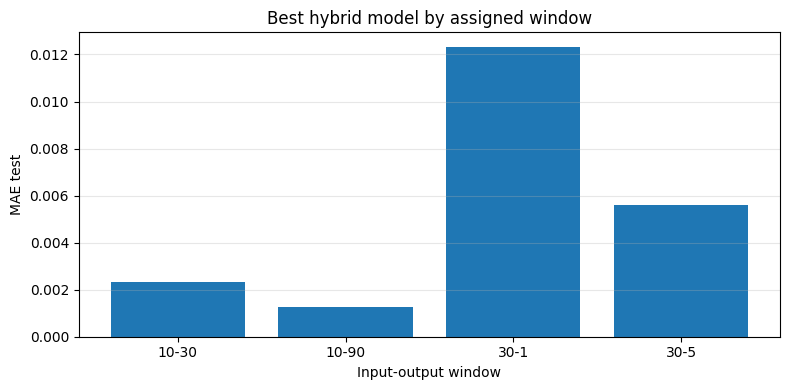

Plot saved to: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mixtos/cnn_rnn_hybrid/hybrid_best_mae_by_window.png


In [7]:
plot_df = best.copy()
plot_df["window"] = plot_df["input_window"].astype(str) + "-" + plot_df["output_window"].astype(str)

fig = plt.figure(figsize=(8, 4))
plt.bar(plot_df["window"], plot_df["MAE_test"])
plt.xlabel("Input-output window")
plt.ylabel("MAE test")
plt.title("Best hybrid model by assigned window")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plot_path = DATA_OUT / "hybrid_best_mae_by_window.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)